# Justificativas das Escolhas e Implementação

Este notebook documenta as etapas iniciais de um projeto de Feature Engineering para um problema de risco de crédito. O objetivo é construir um modelo base usando Regressão Logística e, em seguida, iterar sobre as técnicas de Feature Engineering para melhorar a performance, focando em métricas relevantes para problemas de classificação desbalanceada, como Recall para a classe minoritária ('Mau=1') e ROC AUC.

As justificativas para as escolhas de código e as etapas implementadas são detalhadas abaixo:

## Célula 1: Importação de Bibliotecas Essenciais

**Justificativa:**

A importação de bibliotecas é o primeiro passo em qualquer projeto de análise de dados e machine learning. As bibliotecas selecionadas são fundamentais para as tarefas que serão realizadas:

*   **`pandas` e `numpy`:** Essenciais para manipulação e análise de dados tabulares. Pandas DataFrames são a estrutura principal para trabalhar com o dataset.
*   **`matplotlib.pyplot` e `seaborn`:** Utilizadas para visualização de dados (Análise Exploratória e visualização de resultados como a Matriz de Confusão e Curva ROC).
*   **`sklearn`:** A biblioteca padrão em Python para machine learning. Inclui módulos para:
    *   `model_selection`: Divisão de dados (train/test split).
    *   `preprocessing`: Imputação de valores ausentes (`SimpleImputer`), normalização (`StandardScaler`) e codificação de variáveis categóricas (`OneHotEncoder`). Essas são técnicas centrais de Feature Engineering.
    *   `linear_model`: O modelo de Regressão Logística, escolhido como modelo base para avaliação do impacto das features.
    *   `pipeline`: Para criar pipelines que sequenciam o pré-processamento e o modelo, garantindo que as transformações sejam aplicadas consistentemente aos dados de treino e teste.
    *   `compose`: `ColumnTransformer` permite aplicar diferentes transformações a diferentes colunas, o que é crucial ao lidar com features numéricas e categóricas simultaneamente.
    *   `metrics`: Para avaliar a performance do modelo utilizando métricas como acurácia, matriz de confusão, relatório de classificação (precision, recall, f1-score) e ROC AUC.
*   **Configurações de visualização:** `%matplotlib inline` e `pd.set_option('display.max_columns', None)` facilitam a exibição de gráficos e DataFrames no notebook.

In [ ]:
# Célula 1: Importar Bibliotecas
# Importar bibliotecas essenciais para análise de dados, pré-processamento e modelagem.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

# Configurações para visualização
%matplotlib inline
pd.set_option('display.max_columns', None)

## Célula 2: Definição de Constantes e Nomes de Colunas

**Justificativa:**

Definir constantes e nomes de colunas no início do script melhora a legibilidade e a manutenibilidade do código.

*   **`DATA_URL`:** Armazenar o URL do dataset em uma variável facilita a modificação caso o local do arquivo mude. É uma boa prática para tornar o código mais flexível.
*   **`RANDOM_SEED`:** Definir uma semente aleatória garante a reprodutibilidade dos resultados em etapas que envolvem aleatoriedade (como a divisão treino/teste e inicialização do modelo). Isso é fundamental para comparar o impacto das diferentes técnicas de Feature Engineering de forma justa.
*   **`COLUMNS_NAMES`:** Atribuir nomes significativos às colunas com base no dicionário de dados fornecido é crucial, pois o dataset original não possui cabeçalho. Isso torna o DataFrame compreensível e facilita a referência às features durante o Feature Engineering e a modelagem.

In [ ]:
# Célula 2: Definição de Constantes e Nomes de Colunas
# Definir o URL do dataset conforme o PDF [cite: 45]
DATA_URL = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Definir a semente aleatória (random_seed) para garantir reprodutibilidade, como exigido [cite: 20]
RANDOM_SEED = 42

# Criar a lista de nomes de colunas com base no Dicionário de Dados (páginas 5-6) [cite: 37, 40]
# São 54 colunas no total.
COLUMNS_NAMES = [
    "ID CLIENTE", "TIPO FUNCIONARIO", "DIA PAGAMENTO", "TIPO ENVIO APLICACAO", "QUANT CARTOES ADICIONAIS",
    "TIPO ENDERECO POSTAL", "SEXO", "ESTADO CIVIL", "QUANT DEPENDENTES", "NIVEL EDUCACIONAL",
    "ESTADO NASCIMENTO", "CIDADE NASCIMENTO", "NACIONALIDADE", "ESTADO RESIDENCIAL", "CIDADE RESIDENCIAL",
    "BAIRRO RESIDENCIAL", "FLAG TELEFONE RESIDENCIAL", "CODIGO AREA TELEFONE RESIDENCIAL", "TIPO RESIDENCIA",
    "MESES RESIDENCIA", "FLAG TELEFONE MOVEL", "FLAG EMAIL", "RENDA PESSOAL MENSAL", "OUTRAS RENDAS",
    "FLAG VISA", "FLAG MASTERCARD", "FLAG DINERS", "FLAG AMERICAN EXPRESS", "FLAG OUTROS CARTOES",
    "QUANT CONTAS BANCARIAS", "QUANT CONTAS BANCARIAS ESPECIAIS", "VALOR PATRIMONIO PESSOAL", "QUANT CARROS",
    "EMPRESA", "ESTADO PROFISSIONAL", "CIDADE PROFISSIONAL", "BAIRRO PROFISSIONAL", "FLAG TELEFONE PROFISSIONAL",
    "CODIGO AREA TELEFONE PROFISSIONAL", "MESES NO TRABALHO", "CODIGO PROFISSAO", "ΤΙΡΟ OCUPACAO",
    "CODIGO PROFISSAO CONJUGE", "NIVEL EDUCACIONAL CONJUGE", "FLAG DOCUMENTO RESIDENCIAL", "FLAG RG",
    "FLAG CPF", "FLAG COMPROVANTE RENDA", "PRODUTO", "FLAG REGISTRO ACSP", "IDADE",
    "CEP RESIDENCIAL 3", "CEP PROFISSIONAL 3", "ROTULO ALVO MAU=1"
]

## Célula 3: Carregamento dos Dados

**Justificativa:**

Esta célula realiza o carregamento inicial dos dados.

*   **`pd.read_csv(...)`:** A função padrão do pandas para ler arquivos CSV.
*   **`encoding='unicode_escape'`:** Utilizado para lidar com possíveis caracteres especiais no arquivo que poderiam causar erros de leitura com a codificação padrão.
*   **`sep='\t'`:** Especifica que o separador entre as colunas é uma tabulação (`\t`), conforme indicado na fonte dos dados.
*   **`header=None`:** Informa ao pandas que o arquivo não contém uma linha de cabeçalho, utilizando os nomes fornecidos em `COLUMNS_NAMES`.
*   **`names=COLUMNS_NAMES`:** Atribui os nomes definidos na Célula 2 às colunas do DataFrame.
*   **Tratamento de Exceção:** O bloco `try...except` é adicionado para capturar possíveis erros durante o carregamento (por exemplo, se o URL não estiver acessível), tornando o código mais robusto.
*   **`df.shape` e `df.head()`:** Verificar o formato do DataFrame e exibir as primeiras linhas são etapas essenciais para confirmar se os dados foram carregados corretamente e para ter uma primeira visualização da estrutura. O `DtypeWarning` observado na saída indica que algumas colunas têm tipos mistos, o que será abordado na etapa de limpeza.

In [ ]:
# Célula 3: Carregamento dos Dados
# Carregar os dados usando o comando exato do PDF [cite: 46]
# sep='\t' (separador por tabulação) e header=None (sem cabeçalho)
try:
    df = pd.read_csv(
        DATA_URL,
        encoding='unicode_escape',
        sep='\t',
        header=None,
        names=COLUMNS_NAMES
    )
    print(f"Dataset carregado com sucesso. Formato: {df.shape}")
except Exception as e:
    print(f"Erro ao carregar o dataset: {e}")

print("\n--- Visualização Inicial (head) ---")
display(df.head())

/tmp/ipython-input-3889829563.py:5: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dataset carregado com sucesso. Formato: (50000, 54)

--- Visualização Inicial (head) ---


,ID CLIENTE,TIPO FUNCIONARIO,DIA PAGAMENTO,TIPO ENVIO APLICACAO,QUANT CARTOES ADICIONAIS,TIPO ENDERECO POSTAL,SEXO,ESTADO CIVIL,QUANT DEPENDENTES,NIVEL EDUCACIONAL,ESTADO NASCIMENTO,CIDADE NASCIMENTO,NACIONALIDADE,ESTADO RESIDENCIAL,CIDADE RESIDENCIAL,BAIRRO RESIDENCIAL,FLAG TELEFONE RESIDENCIAL,CODIGO AREA TELEFONE RESIDENCIAL,TIPO RESIDENCIA,MESES RESIDENCIA,FLAG TELEFONE MOVEL,FLAG EMAIL,RENDA PESSOAL MENSAL,OUTRAS RENDAS,FLAG VISA,FLAG MASTERCARD,FLAG DINERS,FLAG AMERICAN EXPRESS,FLAG OUTROS CARTOES,QUANT CONTAS BANCARIAS,QUANT CONTAS BANCARIAS ESPECIAIS,VALOR PATRIMONIO PESSOAL,QUANT CARROS,EMPRESA,ESTADO PROFISSIONAL,CIDADE PROFISSIONAL,BAIRRO PROFISSIONAL,FLAG TELEFONE PROFISSIONAL,CODIGO AREA TELEFONE PROFISSIONAL,MESES NO TRABALHO,CODIGO PROFISSAO,ΤΙΡΟ OCUPACAO,CODIGO PROFISSAO CONJUGE,NIVEL EDUCACIONAL CONJUGE,FLAG DOCUMENTO RESIDENCIAL,FLAG RG,FLAG CPF,FLAG COMPROVANTE RENDA,PRODUTO,FLAG REGISTRO ACSP,IDADE,CEP RESIDENCIAL 3,CEP PROFISSIONAL 3,ROTULO ALVO MAU=1
0,1,C,5,Web,0,1,F,6,1,0,RN,Assu,1,RN,Santana do Matos,Centro,Y,105,1.0,15.0,N,1,900.0,0.0,1,1,0,0,0,0,0,0.0,0,N,,NaN,NaN,N,,0,9.0,4.0,NaN,NaN,0,0,0,0,1,N,32,595,595,1
1,2,C,15,Carga,0,1,F,2,0,0,RJ,rio de janeiro,1,RJ,RIO DE JANEIRO,CAMPO GRANDE,Y,20,1.0,1.0,N,1,750.0,0.0,0,0,0,0,0,0,0,0.0,0,Y,,NaN,NaN,N,,0,11.0,4.0,11.0,NaN,0,0,0,0,1,N,34,230,230,1
2,3,C,5,Web,0,1,F,2,0,0,RN,GARANHUNS,1,RN,Parnamirim,Boa Esperanca,Y,105,1.0,NaN,N,1,500.0,0.0,0,0,0,0,0,0,0,0.0,0,N,,NaN,NaN,N,,0,11.0,NaN,NaN,NaN,0,0,0,0,1,N,27,591,591,0
3,4,C,20,Web,0,1,F,2,0,0,PE,CABO,1,PE,CABO,PONTE DOS CARVALHOS,N,,NaN,NaN,N,1,500.0,0.0,0,0,0,0,0,0,0,0.0,0,N,,NaN,NaN,N,,0,NaN,NaN,NaN,NaN,0,0,0,0,1,N,61,545,545,0
4,5,C,10,Web,0,1,M,2,0,0,RJ,RIO DE JANEIRO,1,RJ,Rio de Janeiro,Santa Cruz,Y,20,1.0,12.0,N,1,1200.0,0.0,0,0,0,0,0,0,0,0.0,0,N,,NaN,NaN,N,,0,9.0,5.0,NaN,NaN,0,0,0,0,1,N,48,235,235,1


## Célula 4: Análise Exploratória Inicial (EDA)

**Justificativa:**

A Análise Exploratória de Dados (EDA) é vital antes de iniciar qualquer processo de Feature Engineering ou modelagem. Esta célula fornece insights cruciais sobre a qualidade e a estrutura dos dados:

*   **`df.info()`:** Mostra o tipo de dado de cada coluna (`Dtype`) e a contagem de valores não nulos. Isso é fundamental para identificar colunas que contêm valores ausentes (NaN) e colunas que foram carregadas com o tipo incorreto (por exemplo, numéricas como 'object' devido a caracteres especiais ou valores ausentes representados como texto).
*   **`df.describe()`:** Fornece estatísticas descritivas básicas para as colunas numéricas (média, desvio padrão, mínimo, máximo, quartis). Ajuda a entender a distribuição dos dados e identificar possíveis outliers.
*   **`df.isnull().sum().sort_values(ascending=False)`:** Calcula a quantidade de valores nulos por coluna e os ordena de forma decrescente. Esta é uma etapa crítica para identificar quais colunas precisam de tratamento de valores ausentes (imputação), uma das técnicas de Feature Engineering a serem aplicadas.
*   **Distribuição da Variável Alvo (`df['ROTULO ALVO MAU=1'].value_counts(normalize=True)` e `sns.countplot(...)`):** Analisar a distribuição da variável alvo é essencial em problemas de classificação. Revela se as classes (Bom=0, Mau=1) estão balanceadas ou desbalanceadas. A visualização com `countplot` confirma o desbalanceamento, o que impactará as métricas de avaliação escolhidas (ROC AUC e métricas do relatório de classificação, como Precision e Recall, são mais informativas que a Acurácia em casos desbalanceados) e potencialmente as técnicas de modelagem ou Feature Engineering (como usar `class_weight='balanced'` na Regressão Logística).


--- Informações do DataFrame (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID CLIENTE                         50000 non-null  int64  
 1   TIPO FUNCIONARIO                   50000 non-null  object 
 2   DIA PAGAMENTO                      50000 non-null  int64  
 3   TIPO ENVIO APLICACAO               50000 non-null  object 
 4   QUANT CARTOES ADICIONAIS           50000 non-null  int64  
 5   TIPO ENDERECO POSTAL               50000 non-null  int64  
 6   SEXO                               50000 non-null  object 
 7   ESTADO CIVIL                       50000 non-null  int64  
 8   QUANT DEPENDENTES                  50000 non-null  int64  
 9   NIVEL EDUCACIONAL                  50000 non-null  int64  
 10  ESTADO NASCIMENTO                  50000 non-null  object 
 11  CIDADE NAS

,ID CLIENTE,DIA PAGAMENTO,QUANT CARTOES ADICIONAIS,TIPO ENDERECO POSTAL,ESTADO CIVIL,QUANT DEPENDENTES,NIVEL EDUCACIONAL,NACIONALIDADE,TIPO RESIDENCIA,MESES RESIDENCIA,FLAG EMAIL,RENDA PESSOAL MENSAL,OUTRAS RENDAS,FLAG VISA,FLAG MASTERCARD,FLAG DINERS,FLAG AMERICAN EXPRESS,FLAG OUTROS CARTOES,QUANT CONTAS BANCARIAS,QUANT CONTAS BANCARIAS ESPECIAIS,VALOR PATRIMONIO PESSOAL,QUANT CARROS,MESES NO TRABALHO,CODIGO PROFISSAO,ΤΙΡΟ OCUPACAO,CODIGO PROFISSAO CONJUGE,NIVEL EDUCACIONAL CONJUGE,FLAG DOCUMENTO RESIDENCIAL,FLAG RG,FLAG CPF,FLAG COMPROVANTE RENDA,PRODUTO,IDADE,ROTULO ALVO MAU=1
count,50000.000000,50000.000000,50000.0,50000.000000,50000.00000,50000.000000,50000.0,50000.000000,48651.000000,46223.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,42244.000000,42687.000000,21116.000000,17662.000000,50000.0,50000.0,50000.0,50000.0,50000.000000,50000.00000,50000.000000
mean,25000.500000,12.869920,0.0,1.006540,2.14840,0.650520,0.0,0.961600,1.252225,9.727149,0.802280,886.678437,35.434760,0.111440,0.097460,0.001320,0.001740,0.002040,0.357840,0.357840,2.322372e+03,0.336140,0.009320,8.061784,2.484316,3.797926,0.296003,0.0,0.0,0.0,0.0,1.275700,43.24852,0.260820
std,14433.901067,6.608385,0.0,0.080606,1.32285,1.193655,0.0,0.202105,0.867833,10.668841,0.398284,7846.959327,891.515142,0.314679,0.296586,0.036308,0.041677,0.045121,0.479953,0.479953,4.235798e+04,0.472392,0.383453,3.220104,1.532261,5.212168,0.955688,0.0,0.0,0.0,0.0,0.988286,14.98905,0.439086
min,1.000000,1.000000,0.0,1.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,6.00000,0.000000
25%,12500.750000,10.000000,0.0,1.000000,1.00000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,360.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,31.00000,0.000000
50%,25000.500000,10.000000,0.0,1.000000,2.00000,0.000000,0.0,1.000000,1.000000,6.000000,1.000000,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,9.000000,2.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,41.00000,0.000000
75%,37500.250000,15.000000,0.0,1.000000,2.00000,1.000000,0.0,1.000000,1.000000,15.000000,1.000000,800.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,0.000000,9.000000,4.000000,11.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,53.00000,1.000000
max,50000.000000,25.000000,0.0,2.000000,7.00000,53.000000,0.0,2.000000,5.000000,228.000000,1.000000,959000.000000,194344.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,6.000000e+06,1.000000,35.000000,18.000000,5.000000,17.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.00000,1.000000



--- Contagem de Valores Nulos (NaN) ---
BAIRRO PROFISSIONAL                  33783
CIDADE PROFISSIONAL                  33783
NIVEL EDUCACIONAL CONJUGE            32338
CODIGO PROFISSAO CONJUGE             28884
CODIGO PROFISSAO                      7756
ΤΙΡΟ OCUPACAO                         7313
MESES RESIDENCIA                      3777
TIPO RESIDENCIA                       1349
TIPO ENDERECO POSTAL                     0
QUANT CARTOES ADICIONAIS                 0
ESTADO NASCIMENTO                        0
CIDADE NASCIMENTO                        0
QUANT DEPENDENTES                        0
NIVEL EDUCACIONAL                        0
ESTADO RESIDENCIAL                       0
NACIONALIDADE                            0
SEXO                                     0
ESTADO CIVIL                             0
DIA PAGAMENTO                            0
TIPO ENVIO APLICACAO                     0
ID CLIENTE                               0
TIPO FUNCIONARIO                         0
FLAG EMAIL   

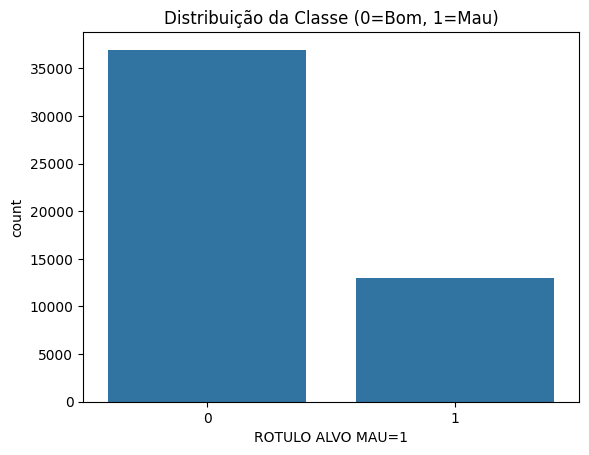

In [ ]:
# Célula 4: Análise Exploratória Inicial (EDA)
print("\n--- Informações do DataFrame (df.info) ---")
# Essencial para identificar os tipos de dados (Dtypes) e valores nulos
df.info()

print("\n--- Estatísticas Descritivas (df.describe) ---")
# Foco nas colunas numéricas
display(df.describe())

print("\n--- Contagem de Valores Nulos (NaN) ---")
# Identificar colunas que precisarão de imputação [cite: 16]
print(df.isnull().sum().sort_values(ascending=False))

print("\n--- Distribuição da Variável Alvo ---")
# Verificar o balanceamento das classes (BOM=0, MAU=1)
print(df['ROTULO ALVO MAU=1'].value_counts(normalize=True))
sns.countplot(x='ROTULO ALVO MAU=1', data=df)
plt.title('Distribuição da Classe (0=Bom, 1=Mau)')
plt.show()

## Célula 5: Limpeza e Conversão de Tipos

**Justificativa:**

Como observado na EDA (`df.info()` e no `DtypeWarning`), algumas colunas numéricas foram lidas como 'object' devido a formatos inconsistentes (como o uso de vírgula como separador decimal) ou outros caracteres não numéricos. Esta célula aborda essa limpeza e conversão, que é uma forma básica, mas fundamental, de Feature Engineering/Pré-processamento:

*   **`df_proc = df.copy()`:** Cria uma cópia do DataFrame original para realizar as transformações. Isso preserva os dados originais caso seja necessário consultá-los ou iniciar o pré-processamento de outra forma.
*   **Identificação de Colunas:** A lista `numeric_cols_to_convert` identifica as colunas que se espera serem numéricas, mas que podem ter sido lidas incorretamente.
*   **Substituição de Vírgula por Ponto:** O loop itera sobre as colunas identificadas. Para colunas do tipo 'object', a vírgula (`,`) é substituída por ponto (`.`) usando `.str.replace(',', '.', regex=False)`. Isso padroniza o formato decimal para que o pandas possa interpretá-lo corretamente como número.
*   **`pd.to_numeric(..., errors='coerce')`:** Converte a coluna para tipo numérico (`float64`). O argumento `errors='coerce'` é crucial: ele transformará quaisquer valores que *não* possam ser convertidos para número (mesmo após a substituição da vírgula) em `NaN` (Not a Number). Isso garante que a coluna seja numérica e que os valores problemáticos sejam explicitamente marcados como ausentes, permitindo o tratamento posterior com imputação.
*   **`df_proc[numeric_cols_to_convert].info()`:** Exibir o `info()` apenas para as colunas convertidas confirma que a conversão foi bem-sucedida e que os tipos de dados agora são numéricos, conforme esperado. Esta é uma validação importante da etapa de limpeza.

In [ ]:
# Célula 5: Limpeza e Conversão de Tipos (Parte do Feature Engineering)
# -----------------------------------------------------------------------------
# IMPORTANTE: Como visto no df.info(), muitas colunas que deveriam ser numéricas
# (ex: 'RENDA PESSOAL MENSAL', 'IDADE') podem ser carregadas como 'object' (texto).
# Isso acontece por causa de caracteres especiais (ex: vírgula como decimal) ou
# valores ausentes representados como texto.
# -----------------------------------------------------------------------------

# Crie uma cópia para o pré-processamento
df_proc = df.copy()

# Exemplo de conversão (AJUSTE CONFORME NECESSÁRIO):
# Esta etapa é crucial e pode exigir mais colunas.
# 'errors='coerce'' transforma valores inválidos em NaT/NaN.
numeric_cols_to_convert = [
    'RENDA PESSOAL MENSAL', 'OUTRAS RENDAS', 'VALOR PATRIMONIO PESSOAL',
    'MESES RESIDENCIA', 'IDADE', 'MESES NO TRABALHO'
]

# Substituir vírgula por ponto para decimais (comum em dados brasileiros)
for col in numeric_cols_to_convert:
    if df_proc[col].dtype == 'object':
        df_proc[col] = df_proc[col].astype(str).str.replace(',', '.', regex=False)
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

print("Tipos de dados após conversão:")
df_proc[numeric_cols_to_convert].info()

Tipos de dados após conversão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RENDA PESSOAL MENSAL      50000 non-null  float64
 1   OUTRAS RENDAS             50000 non-null  float64
 2   VALOR PATRIMONIO PESSOAL  50000 non-null  float64
 3   MESES RESIDENCIA          46223 non-null  float64
 4   IDADE                     50000 non-null  int64  
 5   MESES NO TRABALHO         50000 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 2.3 MB


## Célula 6: Definição de Features (X) e Alvo (y)

**Justificativa:**

Separar as features (variáveis independentes, `X`) da variável alvo (variável dependente, `y`) é um passo padrão e necessário na preparação de dados para machine learning.

*   **`y = df_proc['ROTULO ALVO MAU=1']`:** Atribui a coluna que contém a variável alvo (`ROTULO ALVO MAU=1`) à variável `y`. Esta é a variável que o modelo tentará prever.
*   **`X = df_proc.drop(['ROTULO ALVO MAU=1', 'ID CLIENTE'], axis=1)`:** Cria o DataFrame `X` removendo a variável alvo (`ROTULO ALVO MAU=1`) e a coluna `ID CLIENTE` do DataFrame processado (`df_proc`).
    *   Remover a variável alvo é fundamental, pois ela é o que queremos prever, e incluí-la nas features resultaria em *data leakage*, fazendo com que o modelo "veja" a resposta durante o treinamento e superestime sua performance.
    *   Remover `ID CLIENTE` é importante porque é um identificador único para cada linha e não contém informações preditivas úteis para um modelo generalizável. Incluir IDs pode levar o modelo a memorizar instâncias específicas em vez de aprender padrões nos dados.
*   **Verificação de Formato (`X.shape`, `y.shape`):** Imprimir os formatos de `X` e `y` confirma que a separação foi realizada corretamente e que o número de linhas é o mesmo para ambos, com `X` contendo as 52 features restantes.

In [ ]:
# Célula 6: Definição de Features (X) e Alvo (y)
# A variável alvo é 'ROTULO ALVO MAU=1'
# 'ID CLIENTE' é uma chave e deve ser removida das features [cite: 37]

y = df_proc['ROTULO ALVO MAU=1']
X = df_proc.drop(['ROTULO ALVO MAU=1', 'ID CLIENTE'], axis=1)

print(f"Formato de X (features): {X.shape}")
print(f"Formato de y (alvo): {y.shape}")

Formato de X (features): (50000, 52)
Formato de y (alvo): (50000,)


## Célula 7: Divisão dos Dados em Treino e Teste

**Justificativa:**

Dividir os dados em conjuntos de treino e teste é uma prática essencial para avaliar a performance do modelo de forma realista e evitar *overfitting*.

*   **`train_test_split(...)`:** A função do scikit-learn para realizar a divisão.
*   **`test_size=0.3`:** Define que 30% dos dados serão usados para o conjunto de teste, e os 70% restantes para o treino. O conjunto de teste simula dados "novos" que o modelo não viu durante o treinamento.
*   **`random_state=RANDOM_SEED`:** Utiliza a semente aleatória definida anteriormente. Isso garante que a divisão seja sempre a mesma a cada execução do notebook, permitindo comparações consistentes ao testar diferentes técnicas de Feature Engineering.
*   **`stratify=y`:** Este argumento é crucial em problemas de classificação, especialmente com classes desbalanceadas. Ele garante que a proporção da variável alvo (`y`) seja mantida nos conjuntos de treino e teste. Por exemplo, se 26% dos dados originais são da classe 'Mau=1', `stratify=y` garantirá que aproximadamente 26% dos dados em `X_train`, `y_train`, `X_test` e `y_test` também sejam da classe 'Mau=1'. Isso é vital para que a avaliação no conjunto de teste seja representativa.
*   **Verificação de Formato:** Imprimir os formatos dos conjuntos resultantes (`X_train.shape`, `X_test.shape`) confirma que a divisão ocorreu conforme esperado.

In [ ]:
# Célula 7: Divisão dos Dados em Treino e Teste
# Utilizar a mesma 'random_seed' (RANDOM_SEED) é crucial para comparações justas [cite: 20]
# Usar 'stratify=y' é uma boa prática para dados desbalanceados.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, # Definindo 30% para teste (pode ajustar)
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")

Formato de X_train: (35000, 52)
Formato de X_test: (15000, 52)


## Célula 8: Criação dos Pipelines de Feature Engineering

**Justificativa:**

Esta célula constrói os pipelines de pré-processamento usando `Pipeline` e `ColumnTransformer`. A utilização de pipelines é uma prática recomendada no scikit-learn por várias razões:

*   **Sequenciamento Lógico:** Organiza as etapas de pré-processamento em uma sequência clara e reutilizável.
*   **Prevenção de Data Leakage:** Garante que transformações como imputação e escalonamento (que aprendem parâmetros dos dados) sejam ajustadas *apenas* no conjunto de treino (`fit`) e aplicadas (`transform`) tanto no treino quanto no teste. Isso evita que informações do conjunto de teste "vazem" para o processo de aprendizado do modelo.
*   **Código Conciso:** Simplifica o código ao aplicar múltiplas transformações a diferentes tipos de colunas.

**Detalhes da Implementação:**

1.  **Identificação de Colunas:**
    *   `X_train.select_dtypes(...)`: Identifica automaticamente as colunas numéricas e categóricas no conjunto de treino. Isso torna o pipeline mais robusto a mudanças futuras nas colunas do dataset. É importante fazer isso *após* a limpeza inicial de tipos (Célula 5) e *apenas* no `X_train` para evitar leakage.
2.  **Pipeline Numérico (`numeric_transformer`):**
    *   **`SimpleImputer(strategy='median')`:** Seleciona a mediana como estratégia de imputação para colunas numéricas. A mediana é frequentemente preferível à média quando há outliers nos dados (como sugerido pela EDA em colunas de renda/patrimônio), pois é menos sensível a valores extremos.
    *   **`StandardScaler()`:** Aplica a padronização (Z-score). Esta técnica transforma os dados para que tenham média 0 e desvio padrão 1. É essencial para algoritmos que são sensíveis à escala das features, como Regressão Logística com regularização, pois garante que nenhuma feature domine o processo de aprendizado apenas por ter valores maiores.
3.  **Pipeline Categórico (`categorical_transformer`):**
    *   **`SimpleImputer(strategy='most_frequent')`:** Utiliza a moda (valor mais frequente) para imputar valores ausentes em colunas categóricas. Esta é uma estratégia comum e simples para preencher NaNs em dados discretos.
    *   **`FunctionTransformer(lambda x: x.astype(str))`:** Adicionado para garantir que todas as colunas categóricas sejam tratadas como strings antes da codificação. Isso ajuda a evitar erros caso alguma coluna categórica contenha tipos mistos ou valores numéricos que possam confundir o `OneHotEncoder`.
    *   **`OneHotEncoder(handle_unknown='ignore')`:** Aplica a codificação One-Hot. Esta técnica transforma variáveis categóricas em variáveis binárias (0 ou 1) para cada categoria única. É necessário para que algoritmos como a Regressão Logística (que trabalham com valores numéricos) possam processar features categóricas. `handle_unknown='ignore'` instrui o encoder a ignorar categorias que possam aparecer no conjunto de teste, mas não no treino, evitando erros durante a transformação.
4.  **ColumnTransformer (`preprocessor`):**
    *   Combina os pipelines numérico e categórico, aplicando cada um ao conjunto apropriado de colunas identificado anteriormente.
    *   `remainder='passthrough'`: Garante que quaisquer colunas não listadas explicitamente nos transformadores (como colunas 'FLAG...' que já são binárias e podem não precisar de escalonamento) sejam mantidas no output do pré-processamento sem serem transformadas. Isso é útil para manter colunas que já estão em um formato adequado.

In [ ]:
# Célula 8: Criação dos Pipelines de Feature Engineering
# O PDF exige técnicas como imputação, normalização e codificação [cite: 16]

# 1. Identificar automaticamente colunas numéricas e categóricas
# (Isso é feito no X_train para evitar data leakage)
from sklearn.preprocessing import FunctionTransformer # Importar FunctionTransformer

numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

print(f"\nDetectadas {len(numeric_features)} features numéricas.")
print(f"Detectadas {len(categorical_features)} features categóricas.")

# 2. Criar o pipeline para features NUMÉRICAS
# (Imputação de dados + Normalização)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputação com a mediana
    ('scaler', StandardScaler())                     # Normalização (Z-score)
])

# 3. Criar o pipeline para features CATEGÓRICAS
# (Imputação de dados + Codificação)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputação com a moda (valor mais frequente)
    ('to_string', FunctionTransformer(lambda x: x.astype(str))), # Convertendo para string para evitar erro de tipo misto
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # Codificação One-Hot
])

# 4. Combinar os pipelines usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantém colunas não especificadas (se houver)
)


Detectadas 32 features numéricas.
Detectadas 20 features categóricas.


## Célula 9: Criação e Treinamento do Modelo (Regressão Logística)

**Justificativa:**

Esta célula define o modelo de machine learning a ser utilizado e o treina com os dados preparados.

*   **`model = Pipeline(...)`:** Cria o pipeline final que encapsula todo o fluxo: primeiro, aplica o pré-processamento definido na Célula 8 (`preprocessor`); em seguida, alimenta os dados transformados no classificador (`LogisticRegression`). Isso garante que o pré-processamento seja sempre aplicado corretamente antes do treinamento e da previsão.
*   **`LogisticRegression(...)`:** Instancia o modelo de Regressão Logística.
    *   **`random_state=RANDOM_SEED`:** Assegura que a inicialização interna do modelo (se houver) seja determinística, contribuindo para a reprodutibilidade.
    *   **`max_iter=1000`:** Aumenta o número máximo de iterações para o algoritmo de otimização. Em alguns casos, o algoritmo pode precisar de mais iterações para convergir, especialmente com datasets maiores ou features complexas. O aviso `ConvergenceWarning` seria o indicativo para aumentar este valor.
    *   **`class_weight='balanced'`:** Este é um parâmetro importante ao lidar com datasets desbalanceados (como identificado na EDA). Ele ajusta automaticamente os pesos das classes inversamente proporcionais às suas frequências nos dados de entrada. Isso dá mais importância à classe minoritária ('Mau=1') durante o treinamento, ajudando o modelo a aprender melhor os padrões associados a essa classe e potencialmente melhorando o Recall para a classe minoritária.
*   **`model.fit(X_train, y_train)`:** Realiza o treinamento do pipeline completo. O pipeline primeiro ajusta o `preprocessor` (aprendendo medianas, modas, parâmetros do scaler e categorias do one-hot encoder) *apenas* nos dados de treino (`X_train`, `y_train`), e depois transforma `X_train` e treina o `LogisticRegression` com os dados transformados e `y_train`.

In [ ]:
# Célula 9: Criação e Treinamento do Modelo (Regressão Logística)
# O modelo de avaliação deve ser a Regressão Logística

# Criar o pipeline final que inclui o pré-processamento e o classificador
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
    # 'class_weight='balanced'' pode ajudar com classes desbalanceadas
])

# Treinar o modelo
print("Iniciando o treinamento do modelo de Regressão Logística...")
model.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento do modelo de Regressão Logística...
Treinamento concluído.


## Célula 10: Avaliação do Modelo (Métricas)

**Justificativa:**

Avaliar o modelo é crucial para entender sua performance e o impacto das técnicas de Feature Engineering aplicadas. Esta célula calcula e exibe diversas métricas de avaliação no conjunto de TESTE, que o modelo não viu durante o treinamento.

*   **`model.predict(X_test)`:** Gera as previsões de classe (`0` ou `1`) para os dados do conjunto de teste. O pipeline aplica automaticamente o pré-processamento aprendido no treino (`preprocessor.transform(X_test)`) antes de alimentar os dados no classificador para a previsão.
*   **`model.predict_proba(X_test)[:, 1]`:** Obtém as probabilidades previstas para cada classe no conjunto de teste. `[:, 1]` seleciona apenas as probabilidades para a classe positiva ('Mau=1'). As probabilidades são necessárias para calcular o ROC AUC.
*   **Métricas de Avaliação:**
    *   **Acurácia (`accuracy_score`):** A proporção de previsões corretas. Embora útil, a acurácia pode ser enganosa em datasets desbalanceados, pois um modelo que prevê sempre a classe majoritária pode ter alta acurácia, mas ser inútil para a classe minoritária.
    *   **ROC AUC Score (`roc_auc_score`):** A Área Sob a Curva Característica de Operação do Receptor. É uma métrica robusta para datasets desbalanceados, pois mede a capacidade do modelo de distinguir entre as classes. Um ROC AUC de 0.5 indica performance aleatória, enquanto 1.0 indica performance perfeita.
    *   **Matriz de Confusão (`confusion_matrix`, `sns.heatmap`):** Uma tabela que resume a performance do classificador. Mostra o número de Verdadeiros Positivos (VP), Verdadeiros Negativos (VN), Falsos Positivos (FP) e Falsos Negativos (FN). É essencial para entender onde o modelo está errando (por exemplo, quantos maus pagadores estão sendo classificados incorretamente como bons - FN).
    *   **Relatório de Classificação (`classification_report`):** Fornece métricas detalhadas por classe:
        *   **Precision:** Das instâncias previstas como positivas, quantas eram realmente positivas (VP / (VP + FP)). Relevante quando o custo de um FP é alto.
        *   **Recall (Sensibilidade):** Das instâncias realmente positivas, quantas foram corretamente identificadas (VP / (VP + FN)). Crucial em problemas de risco de crédito, onde identificar o máximo de maus pagadores (classe 'Mau=1') é prioritário. **Melhorar o Recall para a classe 1 é um objetivo chave neste projeto.**
        *   **F1-Score:** A média harmônica de Precision e Recall.
        *   **Support:** O número de instâncias reais em cada classe no conjunto de teste.
    *   **Curva ROC (`RocCurveDisplay.from_estimator`):** Uma representação gráfica da performance do classificador em diferentes limiares de classificação. Mostra a taxa de verdadeiros positivos (Recall) vs. a taxa de falsos positivos. Visualizar a curva ajuda a entender a trade-off entre identificar positivos e cometer falsos positivos.

A análise dessas métricas, especialmente o Recall para a classe 'Mau (1)' e o ROC AUC, guiará as iterações futuras de Feature Engineering para melhorar a capacidade do modelo de identificar corretamente os clientes de alto risco.

Avaliando o modelo no conjunto de TESTE...

Acurácia: 0.6292
ROC AUC Score: 0.6103

Matriz de Confusão:


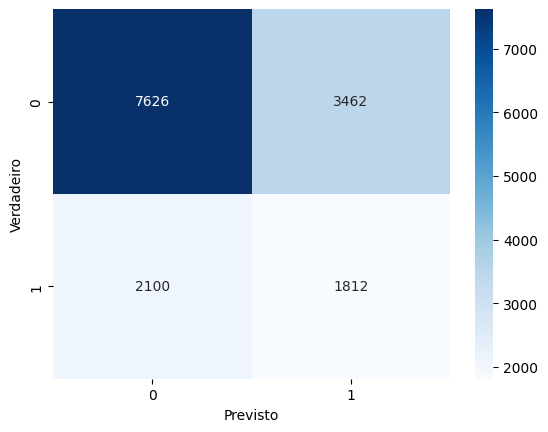


Relatório de Classificação:
              precision    recall  f1-score   support

     Bom (0)       0.78      0.69      0.73     11088
     Mau (1)       0.34      0.46      0.39      3912

    accuracy                           0.63     15000
   macro avg       0.56      0.58      0.56     15000
weighted avg       0.67      0.63      0.64     15000


Curva ROC:


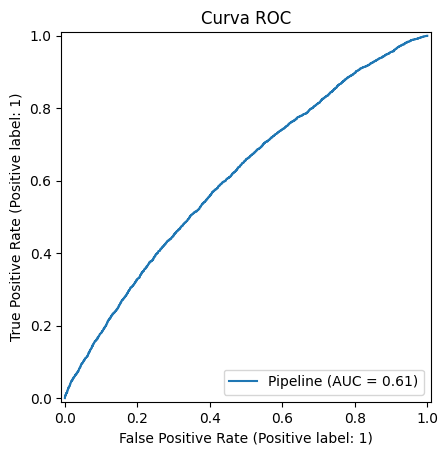

In [ ]:
# Célula 10: Avaliação do Modelo (Métricas)
# O PDF pede as métricas de avaliação para julgar o impacto do feature engineering [cite: 30]

print("Avaliando o modelo no conjunto de TESTE...")
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probabilidades para a classe 1 (Mau)

# 1. Acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

# 2. ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# 3. Matriz de Confusão
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

# 4. Relatório de Classificação (Precision, Recall, F1-Score)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Bom (0)', 'Mau (1)']))

# 5. Curva ROC
print("\nCurva ROC:")
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('Curva ROC')
plt.show()